# Expert 2: Vehicle Dynamics - GMM Training

Train Gaussian Mixture Model for anomaly detection on vehicle dynamics features.

**Expert Focus**: Vehicle motion and orientation
- G-forces (lateral, vertical, longitudinal)
- Velocity components
- Angular velocities
- Vehicle attitude (pitch, roll, yaw)
- Ride height

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.mixture import GaussianMixture
import pickle
import json

# Configuration
SEED = 42
np.random.seed(SEED)

# Paths (relative to notebook location)
ROOT = Path.cwd().parents[1]
DATA_DIR = ROOT / 'data' / 'processed' / 'MoE-anomaly'
SPLITS_DIR = DATA_DIR / 'splits'
SCALERS_DIR = DATA_DIR / 'scalers'
FIGS_DIR = DATA_DIR / 'figs'
MODELS_DIR = ROOT / 'models' / 'anomaly-detection'

# Create directories
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Expert name
EXPERT_NAME = 'expert2_dynamics'

print("Environment setup complete")
print(f"Expert: {EXPERT_NAME}")
print(f"Data directory: {SPLITS_DIR}")
print(f"Models directory: {MODELS_DIR}")

Environment setup complete
Expert: expert2_dynamics
Data directory: c:\Users\usuario\Documents\F1_AC_Digital_Twin\data\processed\MoE-anomaly\splits
Models directory: c:\Users\usuario\Documents\F1_AC_Digital_Twin\models\anomaly-detection


## 1. Load Data

Load preprocessed and normalized vehicle dynamics features.


In [2]:
def load_expert_data(expert_name, splits_dir):
    """
    Load train/val/test data for an expert.
    """
    splits = {}
    for split_name in ['train', 'val', 'test']:
        filepath = splits_dir / f"{expert_name}_{split_name}.csv"
        splits[split_name] = pd.read_csv(filepath)
        print(f"Loaded {split_name}: {len(splits[split_name])} samples")
    
    return splits

# Load data
data_splits = load_expert_data(EXPERT_NAME, SPLITS_DIR)

# Get feature columns (exclude metadata)
META_COLS = ['Timestamp', 'CompletedLaps', 'DistanceTraveled_m', 'CurrentSectorIndex', 'IsInPit']
FEATURE_COLS = [col for col in data_splits['train'].columns if col not in META_COLS]

print(f"\nFeatures: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Loaded train: 46260 samples
Loaded val: 9781 samples
Loaded test: 10084 samples

Features: 16
['AccG_Lateral', 'AccG_Vertical', 'AccG_Longitudinal', 'LocalVelocity_X', 'LocalVelocity_Y', 'LocalVelocity_Z', 'AngularVel_X', 'AngularVel_Y', 'AngularVel_Z', 'Heading', 'Pitch', 'Roll', 'TireLoad_FL', 'TireLoad_FR', 'TireLoad_RL', 'TireLoad_RR']


## 2. Exploratory Data Analysis

Visualize feature distributions and correlations.

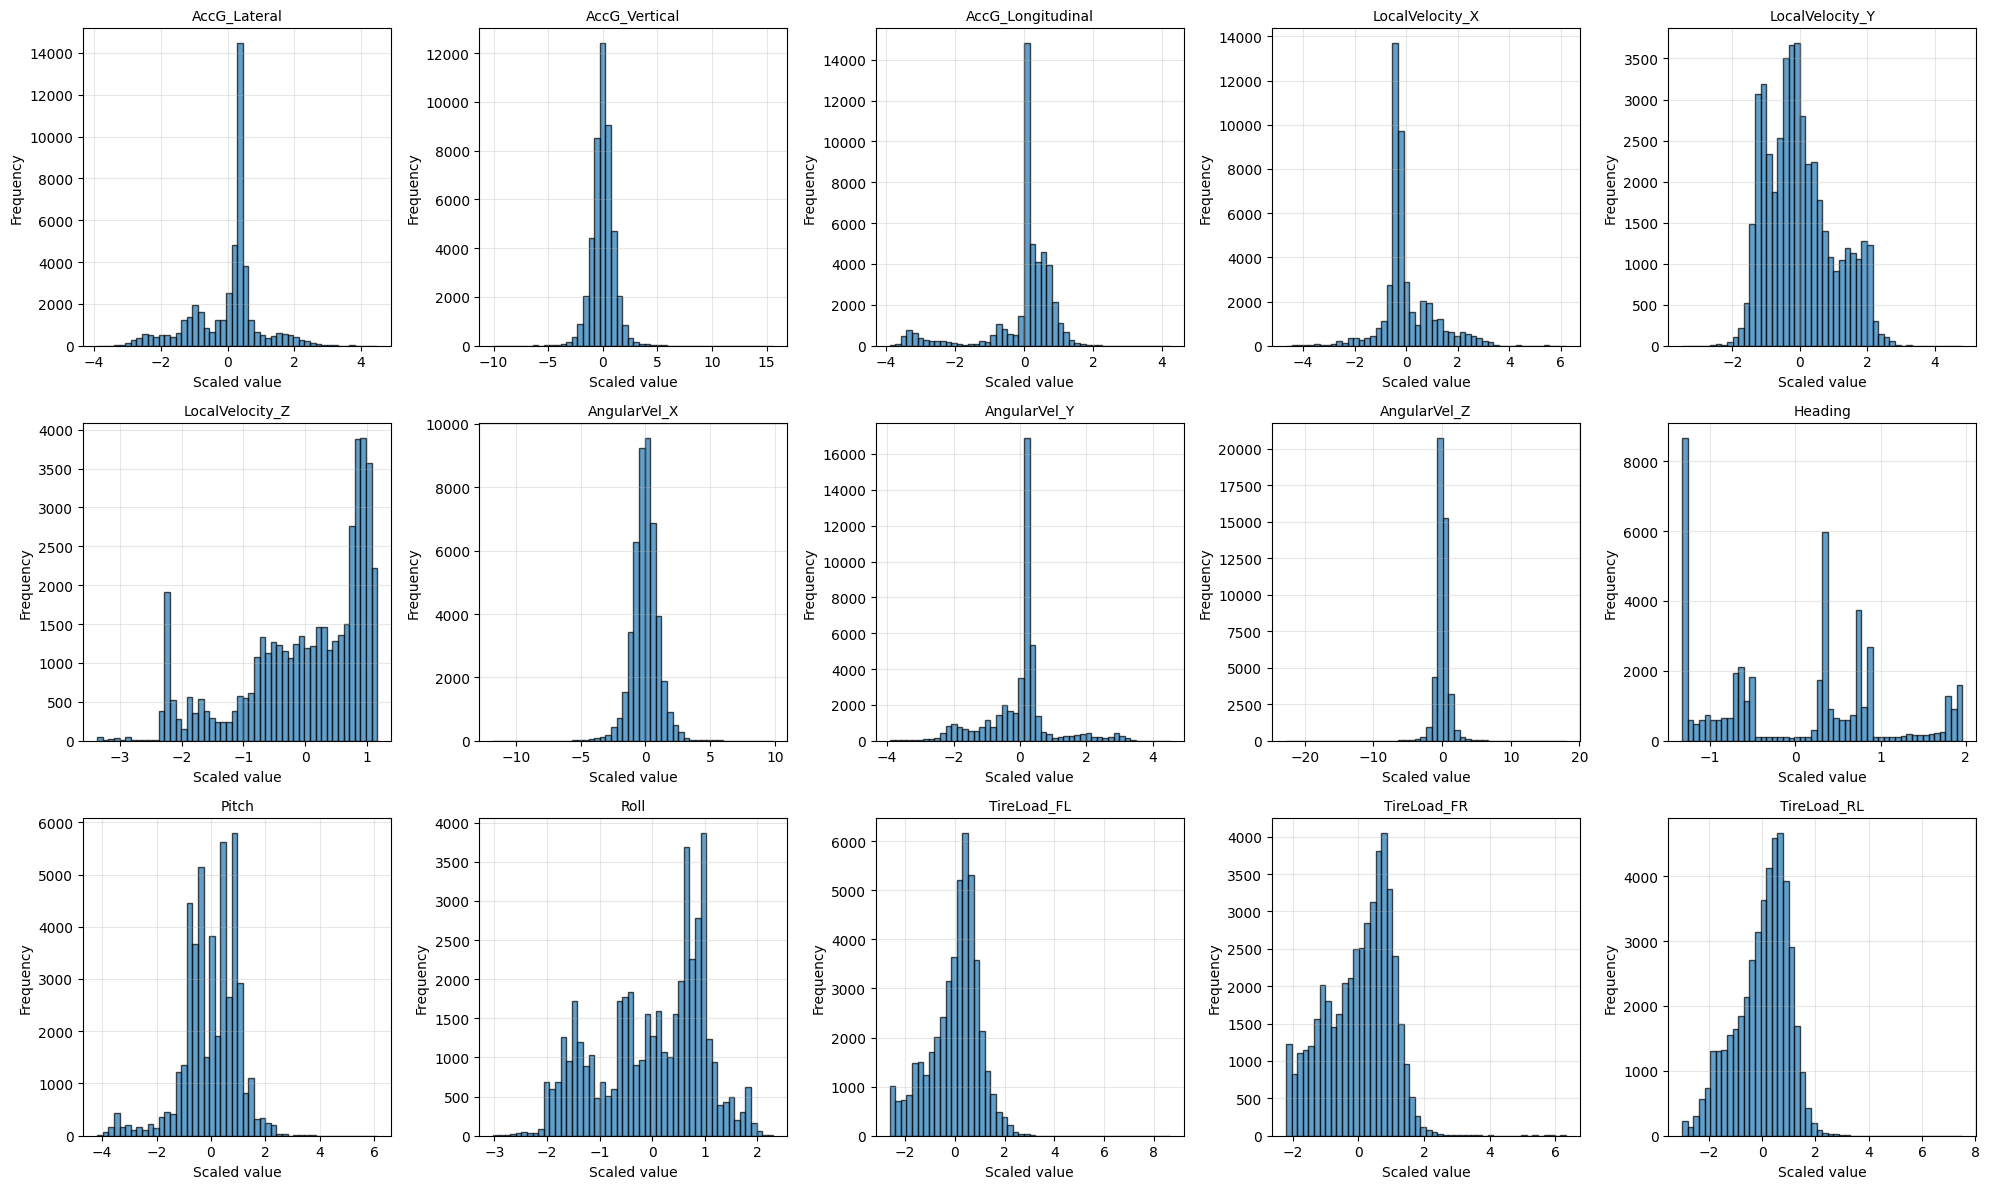

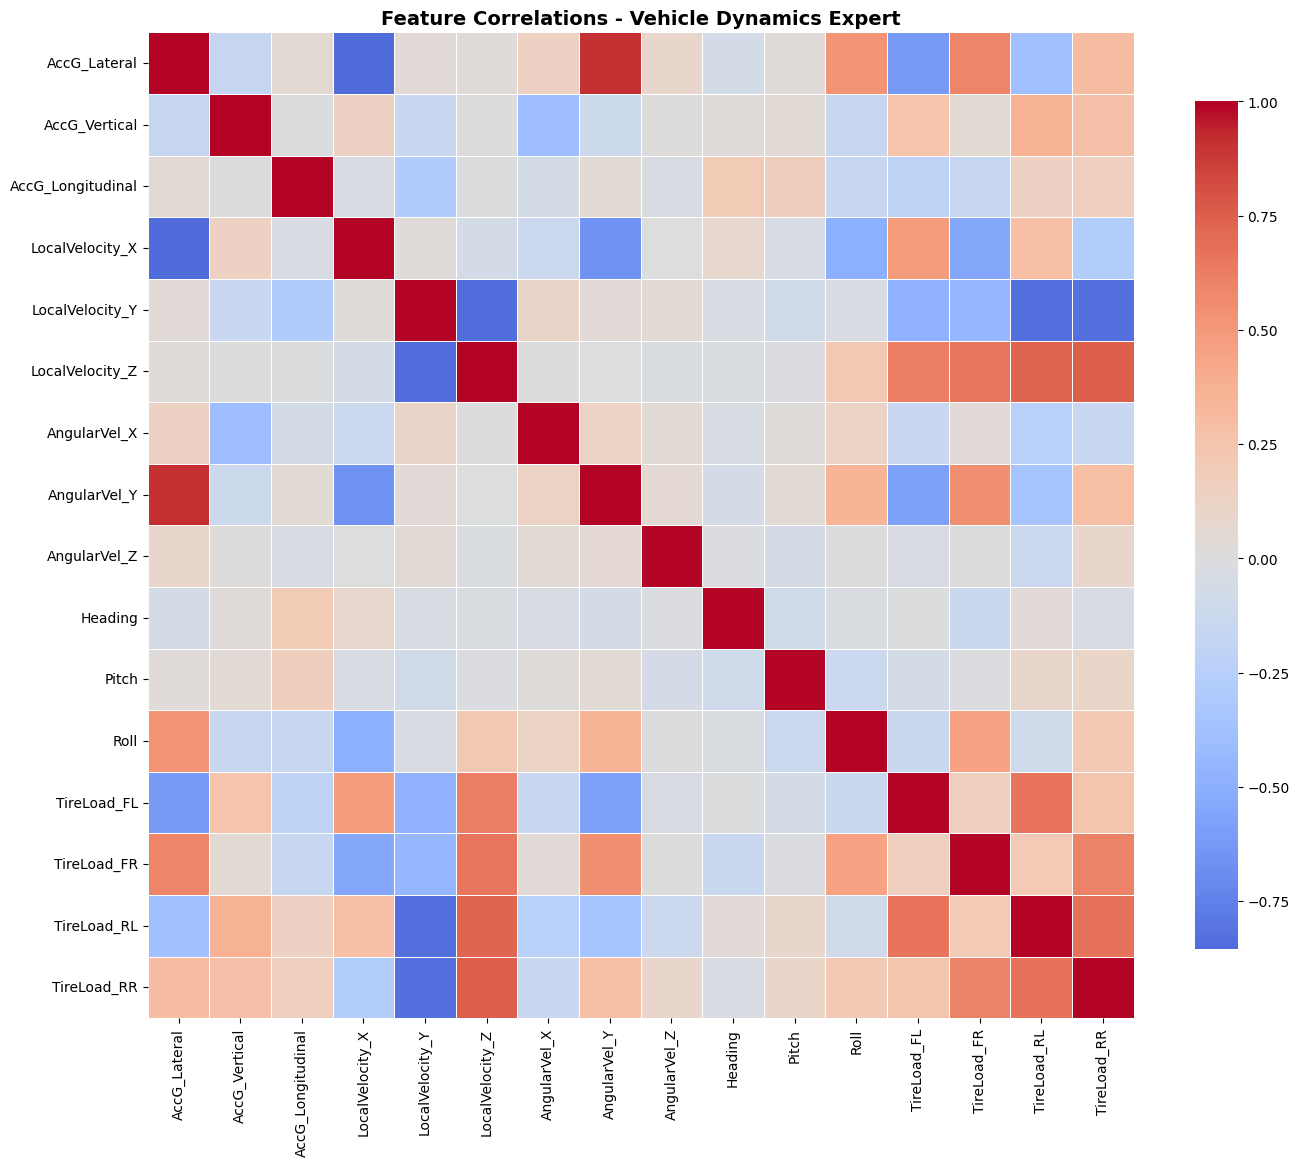

In [3]:
# Plot feature distributions
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

train_data = data_splits['train'][FEATURE_COLS]

for i, feature in enumerate(FEATURE_COLS):
    if i < len(axes):
        ax = axes[i]
        ax.hist(train_data[feature], bins=50, alpha=0.7, edgecolor='black')
        ax.set_title(feature, fontsize=10)
        ax.set_xlabel('Scaled value')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(FEATURE_COLS), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS_DIR / f'{EXPERT_NAME}_distributions.png', dpi=150)
plt.show()

# Correlation heatmap
import seaborn as sns

plt.figure(figsize=(14, 12))
corr = train_data.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlations - Vehicle Dynamics Expert', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / f'{EXPERT_NAME}_correlation.png', dpi=150)
plt.show()

## 3. GMM Training with Hyperparameter Tuning

Train GMMs with different numbers of components and select best using BIC/AIC.

In [4]:
def train_gmm_with_tuning(X_train, X_val, n_components_range=(2, 6)):
    """
    Train GMM models with different number of components.
    Select best based on BIC/AIC on validation set.
    """
    results = []
    
    for n_components in range(n_components_range[0], n_components_range[1]):
        print(f"\nTraining GMM with {n_components} components...")
        
        # Train model
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type='full',
            random_state=SEED,
            max_iter=200,
            n_init=10
        )
        
        gmm.fit(X_train)
        
        # Compute metrics
        train_bic = gmm.bic(X_train)
        train_aic = gmm.aic(X_train)
        val_bic = gmm.bic(X_val)
        val_aic = gmm.aic(X_val)
        
        # Log likelihood
        train_ll = gmm.score(X_train)
        val_ll = gmm.score(X_val)
        
        results.append({
            'n_components': n_components,
            'model': gmm,
            'train_bic': train_bic,
            'train_aic': train_aic,
            'val_bic': val_bic,
            'val_aic': val_aic,
            'train_ll': train_ll,
            'val_ll': val_ll,
            'converged': gmm.converged_
        })
        
        print(f"  Val BIC: {val_bic:.2f}")
        print(f"  Val AIC: {val_aic:.2f}")
        print(f"  Converged: {gmm.converged_}")
    
    return results

# Extract feature data
X_train = data_splits['train'][FEATURE_COLS].values
X_val = data_splits['val'][FEATURE_COLS].values
X_test = data_splits['test'][FEATURE_COLS].values

# Train models
gmm_results = train_gmm_with_tuning(X_train, X_val, n_components_range=(2, 6))


Training GMM with 2 components...


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\usuario\.conda\envs\asseto\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\usuario\.conda\envs\asseto\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\usuario\.conda\envs\asseto\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 108: invalid start byte


  Val BIC: 191899.92
  Val AIC: 189707.52
  Converged: True

Training GMM with 3 components...
  Val BIC: 161419.07
  Val AIC: 158126.88
  Converged: True

Training GMM with 4 components...
  Val BIC: 151258.13
  Val AIC: 146866.14
  Converged: True

Training GMM with 5 components...
  Val BIC: 134611.91
  Val AIC: 129120.13
  Converged: True


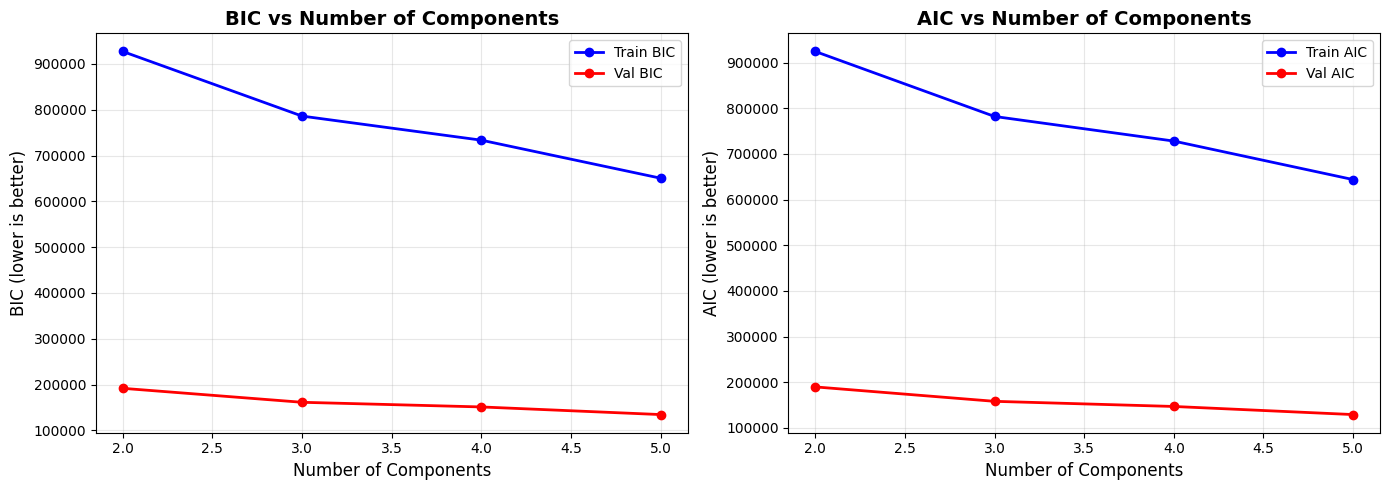

In [5]:
# Plot BIC/AIC curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_comps = [r['n_components'] for r in gmm_results]
train_bics = [r['train_bic'] for r in gmm_results]
val_bics = [r['val_bic'] for r in gmm_results]
train_aics = [r['train_aic'] for r in gmm_results]
val_aics = [r['val_aic'] for r in gmm_results]

# BIC plot
ax1.plot(n_comps, train_bics, 'b-o', label='Train BIC', linewidth=2)
ax1.plot(n_comps, val_bics, 'r-o', label='Val BIC', linewidth=2)
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('BIC (lower is better)', fontsize=12)
ax1.set_title('BIC vs Number of Components', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AIC plot
ax2.plot(n_comps, train_aics, 'b-o', label='Train AIC', linewidth=2)
ax2.plot(n_comps, val_aics, 'r-o', label='Val AIC', linewidth=2)
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('AIC (lower is better)', fontsize=12)
ax2.set_title('AIC vs Number of Components', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / f'{EXPERT_NAME}_model_selection.png', dpi=150)
plt.show()

## 4. Train Best Model

Train final GMM with optimal number of components.

In [6]:
# Select best model based on validation BIC
best_result = min(gmm_results, key=lambda x: x['val_bic'])
best_gmm = best_result['model']
best_n_components = best_result['n_components']

print("=" * 60)
print("BEST MODEL SELECTED")
print("=" * 60)
print(f"Number of components: {best_n_components}")
print(f"Validation BIC: {best_result['val_bic']:.2f}")
print(f"Validation AIC: {best_result['val_aic']:.2f}")
print(f"Converged: {best_result['converged']}")

BEST MODEL SELECTED
Number of components: 5
Validation BIC: 134611.91
Validation AIC: 129120.13
Converged: True


## 5. Component Analysis

Analyze learned GMM components.

In [7]:
print("=" * 60)
print("GMM COMPONENT ANALYSIS")
print("=" * 60)

for i in range(best_gmm.n_components):
    print(f"\nComponent {i+1}:")
    print(f"  Weight: {best_gmm.weights_[i]:.3f} ({best_gmm.weights_[i]*100:.1f}%)")
    print(f"  Mean (first 5 features): {best_gmm.means_[i][:5]}")

# Count samples per component
train_labels = best_gmm.predict(X_train)
unique, counts = np.unique(train_labels, return_counts=True)

print("\nSamples per component:")
for comp, count in zip(unique, counts):
    print(f"  Component {comp}: {count} ({count/len(X_train)*100:.1f}%)")

GMM COMPONENT ANALYSIS

Component 1:
  Weight: 0.210 (21.0%)
  Mean (first 5 features): [ 0.41180167 -0.04722286  0.14067904 -0.38276487 -0.68691576]

Component 2:
  Weight: 0.136 (13.6%)
  Mean (first 5 features): [-1.72440707  0.21153968 -0.47592617  1.5706648   0.82268875]

Component 3:
  Weight: 0.197 (19.7%)
  Mean (first 5 features): [ 0.82766451 -0.06889747 -0.72878226 -0.60810353  1.11927108]

Component 4:
  Weight: 0.242 (24.2%)
  Mean (first 5 features): [-0.05738601  0.0124947   0.14970357  0.00139695 -0.74650429]

Component 5:
  Weight: 0.215 (21.5%)
  Mean (first 5 features): [-0.00774211 -0.03824722  0.66160238 -0.06173795 -0.03548588]

Samples per component:
  Component 0: 9712 (21.0%)
  Component 1: 6293 (13.6%)
  Component 2: 9080 (19.6%)
  Component 3: 11212 (24.2%)
  Component 4: 9963 (21.5%)


## 6. Anomaly Detection

Calculate anomaly scores and set threshold.

In [8]:
def compute_anomaly_scores(gmm, X):
    """
    Compute anomaly scores as negative log-likelihood.
    Higher score = more anomalous.
    """
    log_likelihood = gmm.score_samples(X)
    anomaly_scores = -log_likelihood
    return anomaly_scores

# Compute scores for all splits
scores = {}
for split_name, split_data in data_splits.items():
    X = split_data[FEATURE_COLS].values
    scores[split_name] = compute_anomaly_scores(best_gmm, X)
    print(f"{split_name} - Mean score: {scores[split_name].mean():.3f}, Std: {scores[split_name].std():.3f}")

train - Mean score: 6.942, Std: 10.494
val - Mean score: 6.522, Std: 10.258
test - Mean score: 7.109, Std: 10.906


## 7. Visualize Anomaly Scores

Plot score distributions and anomalies.

Anomaly threshold (95th percentile): 22.232
train: 5.00% anomalies
val: 4.62% anomalies
test: 5.21% anomalies


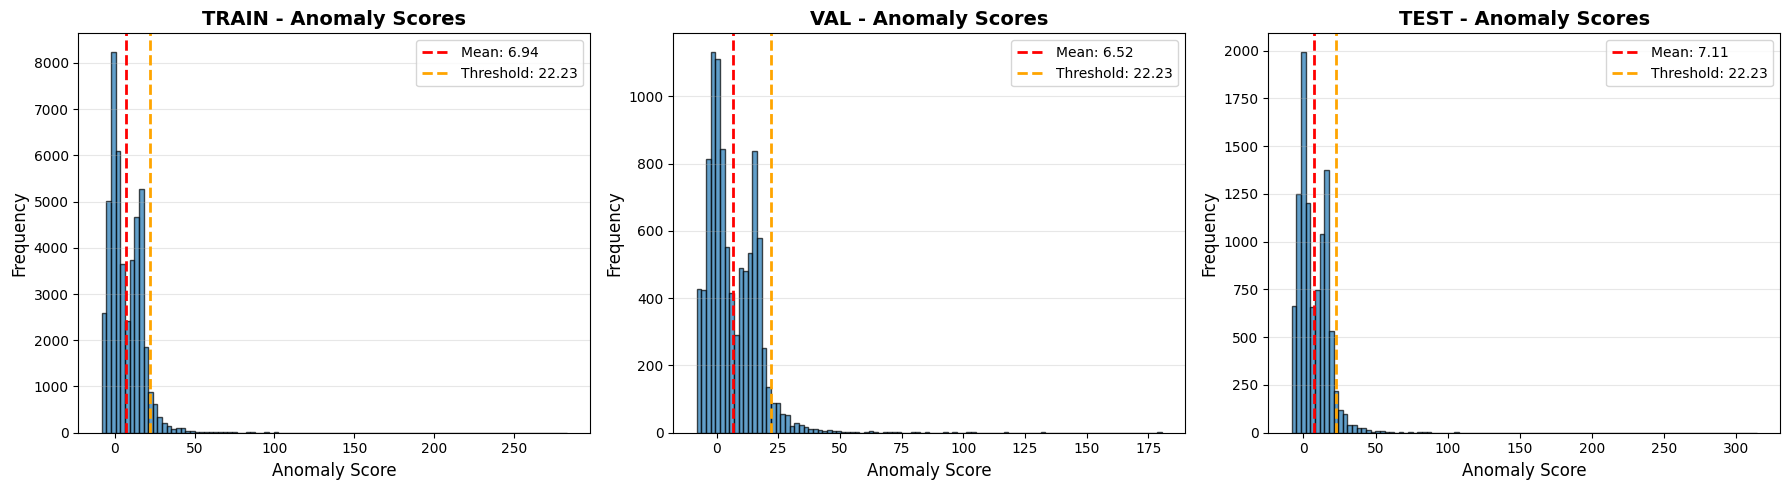

In [9]:
# Define threshold as 95th percentile of training scores
PERCENTILE = 95
threshold = np.percentile(scores['train'], PERCENTILE)

print(f"Anomaly threshold ({PERCENTILE}th percentile): {threshold:.3f}")

# Calculate anomaly rates per split
for split_name, split_scores in scores.items():
    anomaly_rate = (split_scores > threshold).sum() / len(split_scores) * 100
    print(f"{split_name}: {anomaly_rate:.2f}% anomalies")

# Plot anomaly score distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (split_name, split_scores) in zip(axes, scores.items()):
    ax.hist(split_scores, bins=100, alpha=0.7, edgecolor='black')
    ax.axvline(split_scores.mean(), color='r', linestyle='--', linewidth=2, 
               label=f'Mean: {split_scores.mean():.2f}')
    ax.axvline(threshold, color='orange', linestyle='--', linewidth=2,
               label=f'Threshold: {threshold:.2f}')
    ax.set_xlabel('Anomaly Score', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{split_name.upper()} - Anomaly Scores', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGS_DIR / f'{EXPERT_NAME}_anomaly_scores.png', dpi=150)
plt.show()

## 8. Model Summary

Summary of trained model and results.

In [10]:
# Save GMM model
model_path = MODELS_DIR / f'gmm_{EXPERT_NAME}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_gmm, f)

print(f"✅ Model saved to {model_path}")

# Save model metadata
metadata = {
    'expert_name': EXPERT_NAME,
    'n_components': best_n_components,
    'n_features': len(FEATURE_COLS),
    'features': FEATURE_COLS,
    'covariance_type': 'full',
    'threshold': float(threshold),
    'threshold_percentile': PERCENTILE,
    'metrics': {
        'train_bic': float(best_result['train_bic']),
        'val_bic': float(best_result['val_bic']),
        'train_aic': float(best_result['train_aic']),
        'val_aic': float(best_result['val_aic']),
    },
    'converged': bool(best_result['converged']),
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test),
}

metadata_path = MODELS_DIR / f'gmm_{EXPERT_NAME}_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Metadata saved to {metadata_path}")

print("\n" + "=" * 60)
print("EXPERT 2: VEHICLE DYNAMICS - TRAINING COMPLETE")
print("=" * 60)
print(f"\nModel: {best_n_components} component GMM")
print(f"Threshold: {threshold:.3f} (95th percentile)")
print(f"\nFiles saved:")
print(f"  - {model_path.relative_to(ROOT)}")
print(f"  - {metadata_path.relative_to(ROOT)}")
print(f"\nNext: Train Expert 3 (Driver Control) → N03_MoE_expert3_control.ipynb")

✅ Model saved to c:\Users\usuario\Documents\F1_AC_Digital_Twin\models\anomaly-detection\gmm_expert2_dynamics.pkl
✅ Metadata saved to c:\Users\usuario\Documents\F1_AC_Digital_Twin\models\anomaly-detection\gmm_expert2_dynamics_metadata.json

EXPERT 2: VEHICLE DYNAMICS - TRAINING COMPLETE

Model: 5 component GMM
Threshold: 22.232 (95th percentile)

Files saved:
  - models\anomaly-detection\gmm_expert2_dynamics.pkl
  - models\anomaly-detection\gmm_expert2_dynamics_metadata.json

Next: Train Expert 3 (Driver Control) → N03_MoE_expert3_control.ipynb


## 🔍 Component Interpretation

Analyze what each GMM component represents by examining denormalized means.

In [11]:
# Load trained model and scaler
best_gmm = pickle.load(open(MODELS_DIR / 'gmm_expert2_dynamics.pkl', 'rb'))
scaler = pickle.load(open(SCALERS_DIR / 'scaler_expert2_dynamics.pkl', 'rb'))

# Define dynamics features (16 features - UPDATED to include TireLoad_RR)
DYNAMICS_FEATURES = [
    'AccG_Lateral', 'AccG_Vertical', 'AccG_Longitudinal',
    'LocalVelocity_X', 'LocalVelocity_Y', 'LocalVelocity_Z',
    'AngularVel_X', 'AngularVel_Y', 'AngularVel_Z',
    'Heading', 'Pitch', 'Roll',
    'TireLoad_FL', 'TireLoad_FR', 'TireLoad_RL', 'TireLoad_RR'
]

def interpret_gmm_components(gmm, scaler, feature_names):
    """Interpret GMM components by denormalizing means and analyzing distinctive features."""
    
    print("\n" + "="*80)
    print("DETAILED COMPONENT INTERPRETATION")
    print("="*80)
    
    for i in range(gmm.n_components):
        print(f"\n{'='*80}")
        print(f"Component {i+1} - Weight: {gmm.weights_[i]:.3f} ({gmm.weights_[i]*100:.1f}%)")
        print(f"{'='*80}")
        
        # Denormalize mean
        mean_normalized = gmm.means_[i]
        mean_original = scaler.inverse_transform([mean_normalized])[0]
        
        # Get standard deviations (diagonal of covariance)
        std_normalized = np.sqrt(np.diag(gmm.covariances_[i]))
        
        # Show top features by absolute deviation from global mean (0 in normalized space)
        deviations = np.abs(mean_normalized)
        top_indices = np.argsort(deviations)[::-1][:10]  # Top 10 features
        
        print("\nTop 10 most distinctive features:")
        print(f"{'Feature':<20} {'Original Value':<15} {'Normalized':<12} {'Std Dev':<10}")
        print("-" * 80)
        
        for idx in top_indices:
            feat_name = feature_names[idx]
            orig_val = mean_original[idx]
            norm_val = mean_normalized[idx]
            std_val = std_normalized[idx]
            print(f"{feat_name:<20} {orig_val:>12.3f}   {norm_val:>10.3f}   {std_val:>10.3f}")

# Interpret components
interpret_gmm_components(best_gmm, scaler, DYNAMICS_FEATURES)

print("\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)
print("- Original Value: Mean value in original units (G, m/s, rad/s, degrees)")
print("- Normalized: Deviation from global mean in std deviations")
print("- Std Dev: Variability within this component")
print("\nComponents likely represent different driving regimes:")
print("  - Braking zones (high longitudinal G negative, pitch forward)")
print("  - Acceleration (high longitudinal G positive, pitch backward)")
print("  - High-speed corners (high lateral G, roll)")
print("  - Straights (low lateral G, stable orientation)")
print("  - Low-speed corners or transitions (moderate all G forces)")


DETAILED COMPONENT INTERPRETATION

Component 1 - Weight: 0.210 (21.0%)

Top 10 most distinctive features:
Feature              Original Value  Normalized   Std Dev   
--------------------------------------------------------------------------------
LocalVelocity_Z            86.189        0.844        0.199
Roll                        0.011        0.839        0.513
TireLoad_FR              5014.516        0.769        0.415
TireLoad_RR              6227.487        0.736        0.575
LocalVelocity_Y            -0.892       -0.687        0.551
Heading                     0.475        0.563        0.214
Pitch                       0.006       -0.562        1.334
TireLoad_RL              6203.740        0.492        0.596
AccG_Lateral                0.094        0.412        0.172
LocalVelocity_X            -0.008       -0.383        0.200

Component 2 - Weight: 0.136 (13.6%)

Top 10 most distinctive features:
Feature              Original Value  Normalized   Std Dev   
------------------